***
<span style="color:#008385">

**15-288: Machine Learning in a Nutshell**, *CMU-Qatar* Spring'26

**Gianni A. Di Caro**, www.giannidicaro.com

<u>Disclaimer:</u> This notebook was prepared for teaching purposes. It can include material from different web sources. I'll be happy to explicitly acknowledge a source if required. 
</span>
***

***
# Installation: TensorFlow + Keras

**Installing with Anaconda Python 3.12**

- `Keras` is just a wrapper and needs `TensorFlow`. Therefore, the first step is about installing `TensorFlow`, that now includes also Keras:


- To install TensorFlow in the `base` environment of (Ana)conda, in a shell:
 
  ```conda install tensorflow```

- or, inside Anaconda navigator:<br> `Environments` $\to$ `Not Installed` $\to$ Search tensorflow $\to$ select and apply to install

If you encounter dependencies problems, the best option is to install TensorFlow in a dedicated conda environment, e.g., named `tf`:

```conda create -n tf python=3.12 tensorflow jupyterlab```

```conda activate tf```

***
**My experience installing TensorFlow + Keras on MacOS Ventura with Anaconda Pyhton 3.9**

- `Keras` is just a wrapper and needs `TensorFlow`. Therefore, the first step is about installing `TensorFlow`.

- To install TensorFlow on the `base` environment of (Ana)conda doesn't work:
    
    ```conda install tensorflow```

    or, inside Anaconda navigator:<br> `Environments` $\to$ `Not Installed` $\to$ Search tensorflow $\to$ select and apply to install
    
- If Keras is not recognized, you need to install also `keras`
    

- IF the above doesn't work for you, it is useful/necessary to create a new virtual environment for tensorflow and install there all the required packages for using it (including JupyterLab!)
https://docs.anaconda.com/anaconda/user-guide/tasks/tensorflow/#:~:text=Anaconda%20makes%20it%20easy%20to,included%20in%20Anaconda%20and%20Miniconda
<br>At this aim, in the shell:<br>
`conda create -n tf tensorflow`<br>
`conda activate tf`

    - After the above steps, you have a new virtual environment, `tf` with tensorflow. Then, it is necessary to add `keras`, `numpy`, `pandas`, `scikitlearn`, `JupyterLab`. At this aim, it is easier to use the Anaconda navigator interface:<br>
    `Environments` $\to$ `tf`<br> 
    and from there, search among the `Not Installed` packages, select and install the above. In general, you need to install anything that is necessary. 

    - Once all the packages and apps are installed, in the `Home` interface, select the `tf` environment and launch `JupyterLab` from that environment.




***
## Installation of utilities

In addition, for visualizations, it might be useful to install, in the given sequence:

- `pydot`  https://anaconda.org/anaconda/pydot

- `pydotplus` https://anaconda.org/anaconda/pydotplus

- `graphviz`  https://anaconda.org/anaconda/graphviz

In a shell, you shall use the conda command line for installation:

```conda install -c conda-forge pydot```

```conda install -c conda-forge pydotplus```

```conda install -c conda-forge graphviz```

Or, using `tf` environment (which needs to be activated first). 

***
# General imports

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi']= 180
import pandas as pd

import time
from time import process_time 

In [2]:
import tensorflow

#import tensorflow as tf
#print(tf.__version__)

import keras
from keras.models import Sequential

In [3]:
from keras.layers import Dense, Dropout, Activation, Flatten

In [4]:
from keras.utils import to_categorical

***
# (Binary) Classification in the PIMA Indians dataset with MLP 

We have already met this dataset (e.g., in Decision Trees)

In [5]:
pima = pd.read_csv("./datasets/pima-indians-diabetes.csv")

In [6]:
pima

,Pregnancies,Glucose,BP,SkinTickness,Insulin,BMI,PedigreeFunc,Age,Diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [7]:
from sklearn.model_selection import train_test_split 

X_train, X_test,\
Y_train, Y_test = train_test_split(pima.iloc[:, 0:-1].values, 
                                   pima.iloc[:, -1].values, 
                                   test_size=0.25, random_state=99) 

***
## Create the NN model as an MLP


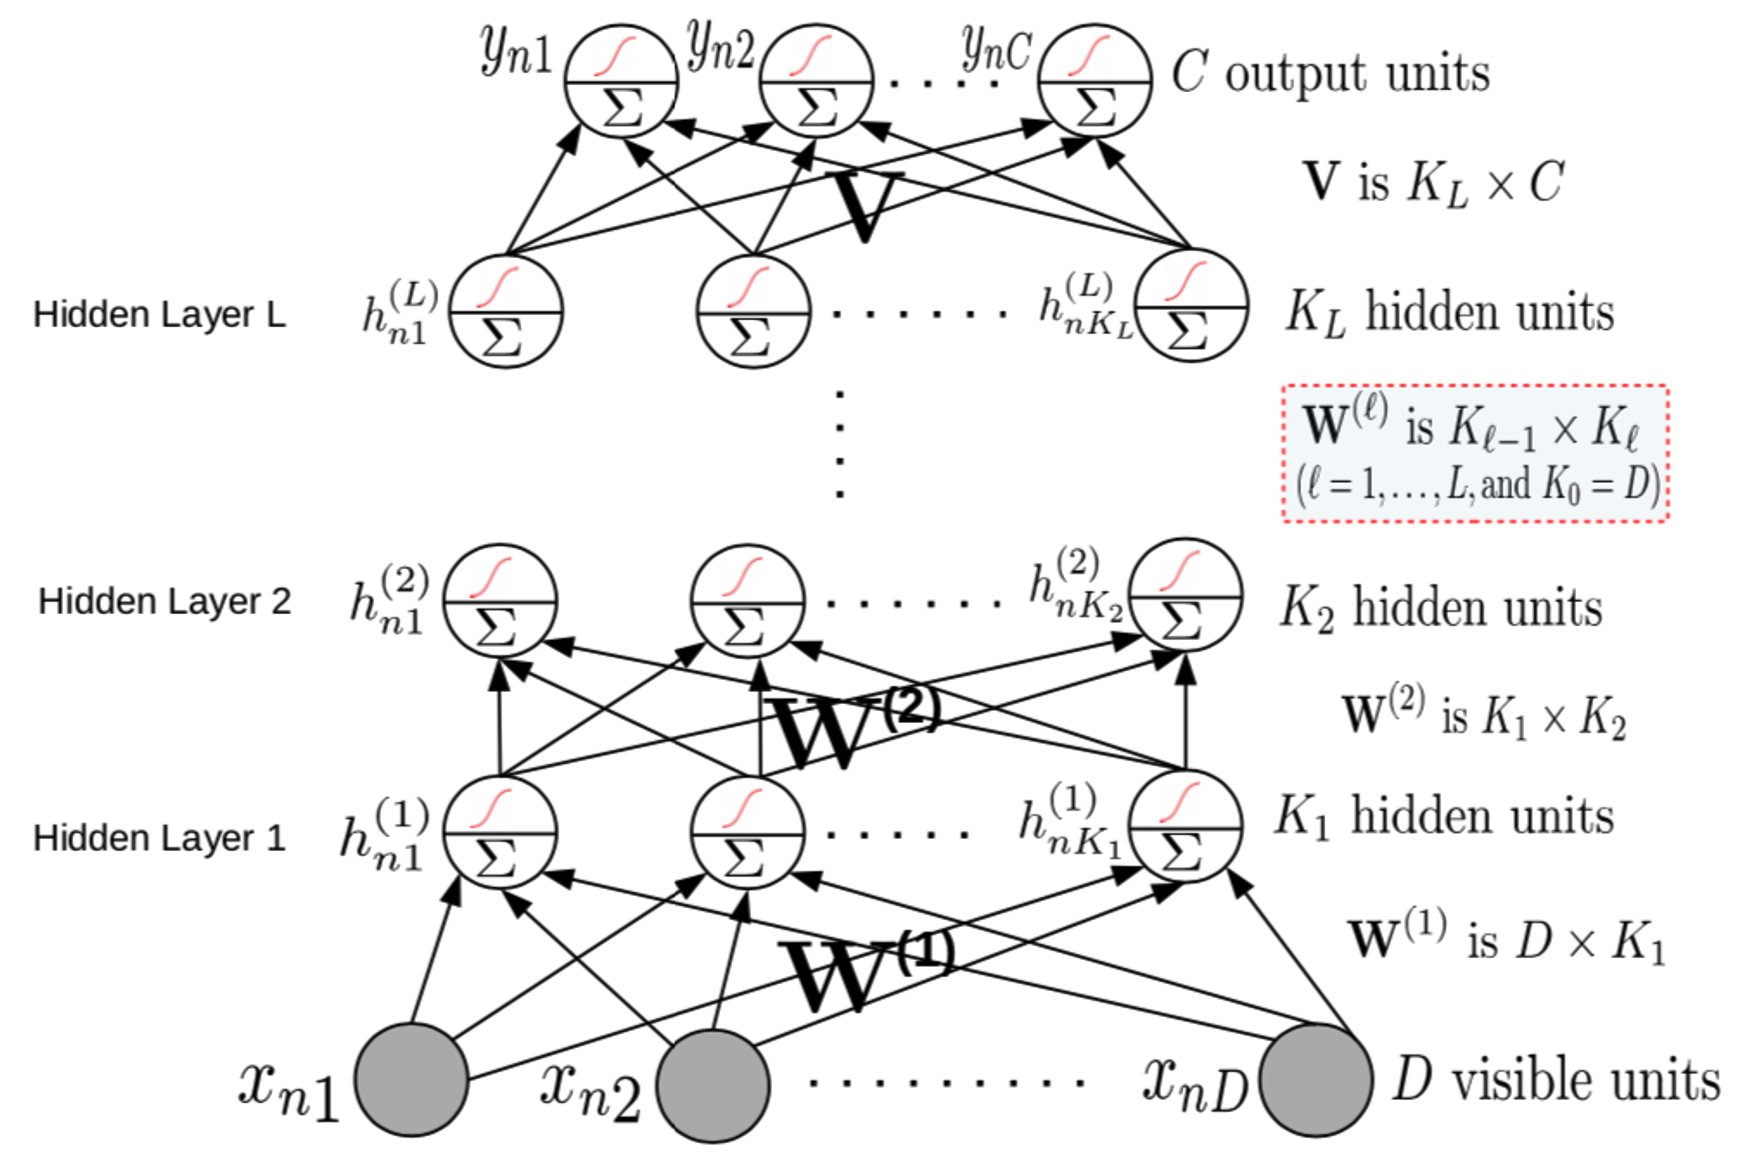

Feed-forward models in Keras are defined as a **sequence of layers.**

This can be obtained by starting creating a `Sequential()` model and add layers one at a time until we complete the desired network architecture.

***
### General layout

Let's decide that we have the following **layered architecture:**
- **One input layer** (*visible* layer)<p>
    
- **Two *hidden* layers**<p>

- **One output layer** (*visible* layer)<p>

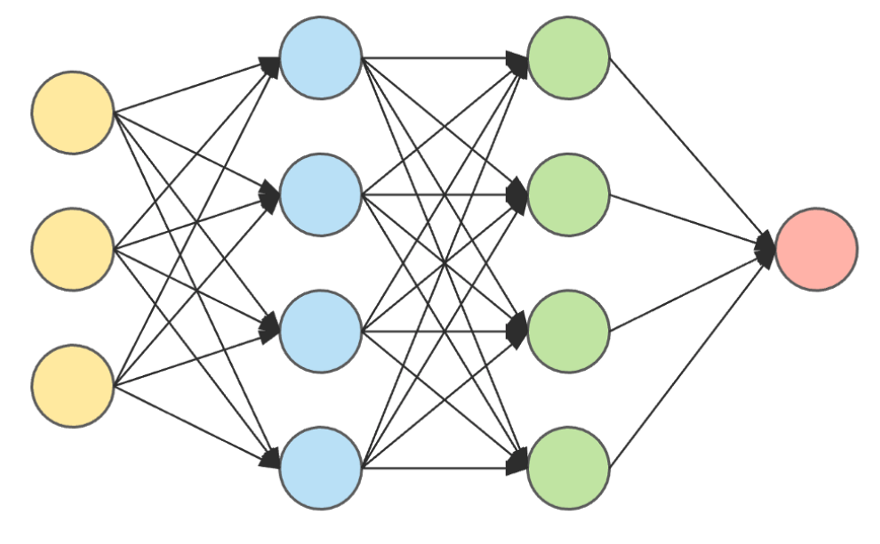

***
### Topology, number of units, activation functions 
    
We need to further decide the number of units in each layer, as well as the activation functions.

- <u>Input layer:</u> 8 inputs/units (one per feature), **ReLU** activation function<p>
- <u>First hidden layer:</u> 12 inputs/units, **ReLU** activation function<p>
    
- <u>Second hidden layer:</u> 8 inputs/units, **ReLU** activation function<p>
- <u>Output layer:</u> 1 input/output unit, for *binary classification,* **Sigmoid** activation function

***
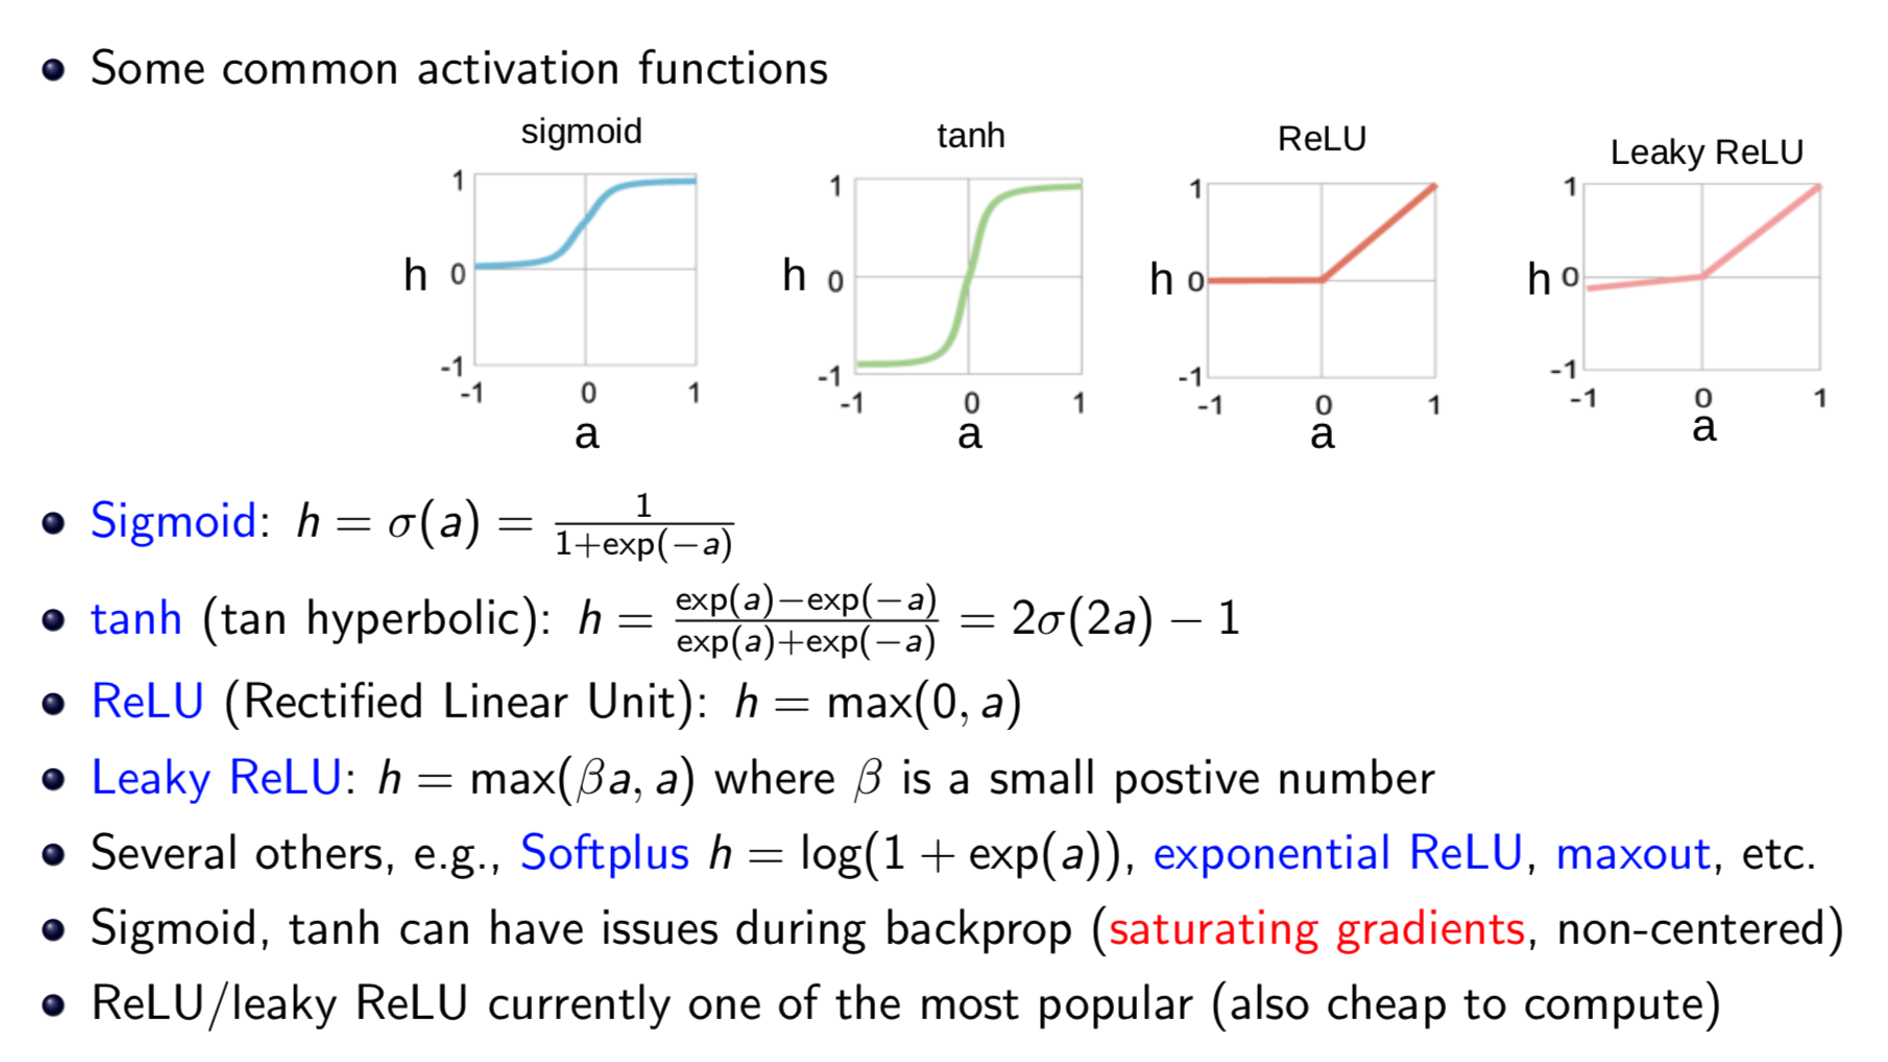

***
### Implementation with Keras 

A **fully connected layer** is created by the method `Dense()`:

`keras.layers.Dense(units, activation=None, use_bias=True, 
                   kernel_initializer='glorot_uniform', 
                   bias_initializer='zeros', 
                   kernel_regularizer=None, 
                   bias_regularizer=None, 
                   activity_regularizer=None, 
                   kernel_constraint=None, bias_constraint=None)`

The parameter `units` define the **dimension of the output space** (i.e., the number of units in the layer).

***
The parameter `input_dim` only applies to the **first hidden layer,** and specifies the number of inputs of the network (and therefore the number of units in the first layer).  


$\to$ The input layer is identified by the presence of the the attribute `input_dim` that specifies the number of the inputs. More precisely, adding an input/visible layer does two things: it adds the input layer *and* the first hidden layer.
***

In [8]:
# to remove warnings from tensorflow
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '1' 

In [9]:
from keras.layers import Dense, Input # Input is a new standard in Keras

MLP_model = Sequential()

# Explicit Input layer
MLP_model.add(Input(shape=(8,)))  

# First hidden layer has 12 units
MLP_model.add(Dense(12, use_bias=True, activation='relu'))

# second hidden layer has 8 units
MLP_model.add(Dense(8, use_bias=True, activation='relu'))

# Output layer, 1 units 
MLP_model.add(Dense(1, use_bias=True, activation='sigmoid'))


***
## Model summary, number of parameters to learn

In [10]:
MLP_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221 (884.00 B)

 Trainable params: 221 (884.00 B)

 Non-trainable params: 0 (0.00 B)

Where those number of parameters come from?

Below the network (note that for the bias inputs they are not shown for all the nodes, and the 1st hidden layer is missing two nodes).

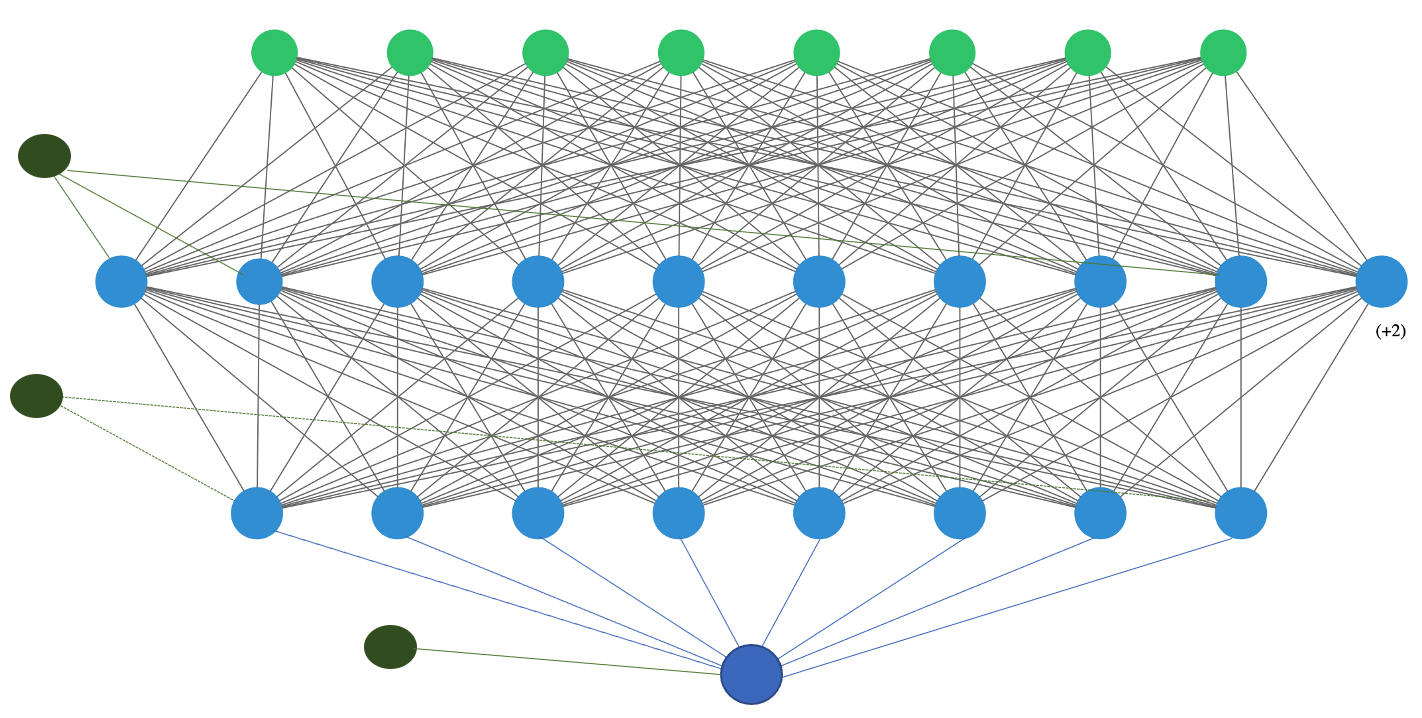


**Input Layer [0]**: Inputs have no weights. Each one of the 8 input units is connected to each of the 12 units of the first hidden layer.

**Hidden Layer 1 [108]**: Each one of the 12 units of the first hidden layer is connected to the 8 input units $\to$ $8\times 12 = 96$ from inputs to HL1. Moreover, each HL1 unit has a *bias* input, that makes a total of $96 + 12 = 108$ weights.

**Hidden Layer 2 [104]**: Each one of the 8 units of the second hidden layer is connected to the 12 units of the first hidden layer $\to$ $12\times 8 = 96$ from HL1 units. Moreover, each HL2 unit has a *bias* input, that makes a total of $96 + 8 = 104$ weights.

**Output Layer 2 [9]**: The single unit of the output layer is connected to the 8 units of HL2 $\to$ $8\times 1 = 8$ from HL2. Moreover, the output unit has a *bias* input, that makes a total of $8 + 1 = 9$ weights.

***
## Visualize the NN model

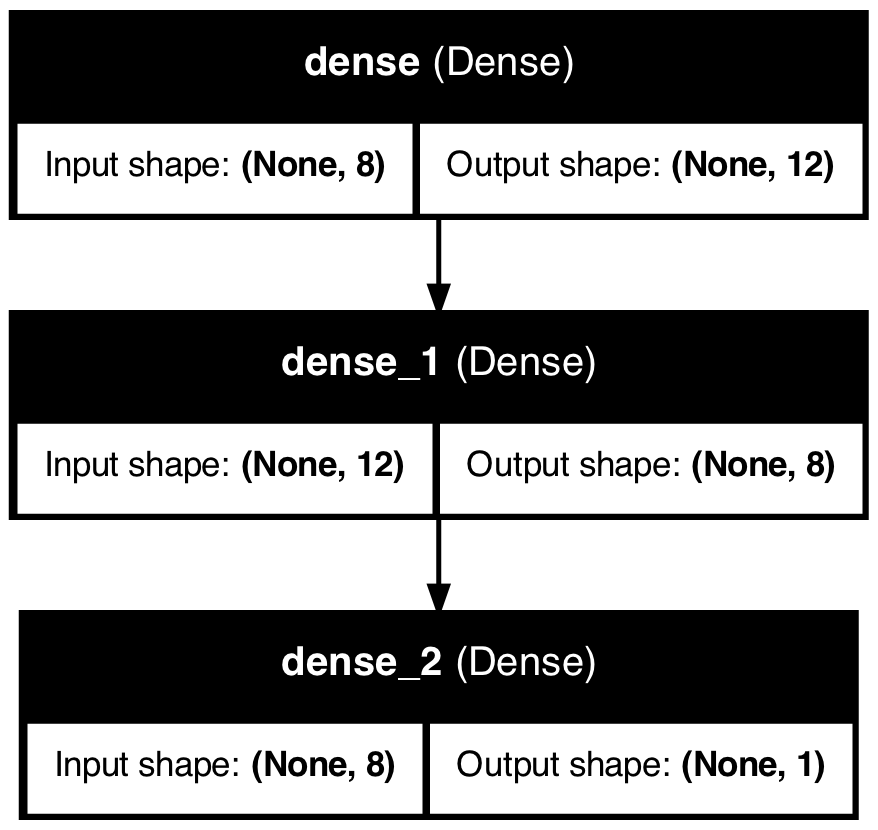

In [11]:
# need to install pydot and pydotplus with conda
#
import pydot
import pydotplus
from keras.utils import plot_model

plot_model(MLP_model, show_shapes=True, show_layer_names=True,
          dpi=180) #to_file='model_plot.png', 

***
$\to$ Note: those numbers in the name of the layers do not really mean anything useful, are just incremental indexes.

***
Visualizing the entire structure of the net might be unfeasible / inappropriate ...

***
## Compile the model

Compiling the model amounts to make it ready for training, by specifying the **loss function,** the **optimizer** for finding the weights, the **metric** to score the performance. 

In [12]:
MLP_model.compile(loss='binary_crossentropy', 
                  optimizer='adam', metrics=['accuracy'])

In [13]:
#help(keras.losses)

In [14]:
#help(keras.optimizers)

***
## Train the model

Based on the mode of operation of the gradient descent approach commonly used to train a NN, training occurs over multiple **epochs** and each epoch is split into **batches**.

- **Epoch:** One optimization pass through all of the examples in the training dataset.<p>

- **Batch:** A subset of the samples are considered (e.g., selected at random) for computing a gradient step and update the NN weights accordingly (similarly to what happens in the Perceptron).

One epoch is comprised of one or more batches, based on the chosen batch size, and the model can be updated for many epochs. 

***
$\to$ Fit can comprise **cross-validation** of the results by setting the `validation_split` parameter.

In [15]:
learning_evolution = MLP_model.fit(X_train, Y_train, epochs=150, 
                                   batch_size=10, #shuffle=True,
                                   validation_split=0.25)

Epoch 1/150
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6354 - loss: 7.4614 - val_accuracy: 0.6042 - val_loss: 2.2256
Epoch 2/150
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 798us/step - accuracy: 0.5843 - loss: 2.2416 - val_accuracy: 0.5278 - val_loss: 1.4655
Epoch 3/150
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 695us/step - accuracy: 0.5205 - loss: 1.3869 - val_accuracy: 0.5694 - val_loss: 1.1784
Epoch 4/150
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 772us/step - accuracy: 0.5128 - loss: 1.0877 - val_accuracy: 0.5486 - val_loss: 1.0079
Epoch 5/150
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 812us/step - accuracy: 0.6013 - loss: 0.8309 - val_accuracy: 0.5486 - val_loss: 0.9226
Epoch 6/150
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 684us/step - accuracy: 0.5819 - loss: 0.8564 - val_accuracy: 0.6597 - val_loss: 0.9485
Epoch 7/150
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 659us/step - accuracy: 0.6095 - loss: 0.8066 - val_accuracy: 0.6458 - val_loss: 0.7917
Epoch 8/150
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 694us/step - accuracy: 0.6129 - loss: 0.7673 - val_accura

In [16]:
help(MLP_model.fit)

Help on method fit in module keras.src.backend.tensorflow.trainer:

fit(x=None, y=None, batch_size=None, epochs=1, verbose='auto', callbacks=None, validation_split=0.0, validation_data=None, shuffle=True, class_weight=None, sample_weight=None, initial_epoch=0, steps_per_epoch=None, validation_steps=None, validation_batch_size=None, validation_freq=1) method of keras.src.models.sequential.Sequential instance
    Trains the model for a fixed number of epochs (dataset iterations).

    Args:
        x: Input data. It could be:
            - A NumPy array (or array-like), or a list of arrays
            (in case the model has multiple inputs).
            - A tensor, or a list of tensors
            (in case the model has multiple inputs).
            - A dict mapping input names to the corresponding array/tensors,
            if the model has named inputs.
            - A `tf.data.Dataset`. Should return a tuple
            of either `(inputs, targets)` or
            `(inputs, targets, s

***
## Plot learning curve

In [17]:
def show_learning_curves(learning_evolution, title='', legend_loc='upper left'):

    # list all data stored in the learning_evolution object
    print('Stored information:', [h for h in learning_evolution.history.keys()])

    # show evolution of accuracy
    plt.plot(learning_evolution.history['accuracy'], label='train')

    # show evolution of cross-validated accuracy
    if 'val_accuracy' in learning_evolution.history:
        plt.plot(learning_evolution.history['val_accuracy'], label='test')

    plt.title(title + 'Model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')

    plt.legend(loc=legend_loc)
    plt.show()

    # show evolution of loss
    plt.plot(learning_evolution.history['loss'])
    
     # show evolution of cross-validated loss
    if 'val_accuracy' in learning_evolution.history:
        plt.plot(learning_evolution.history['val_loss'])

    plt.title(title + 'Model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.show()

Stored information: ['accuracy', 'loss', 'val_accuracy', 'val_loss']


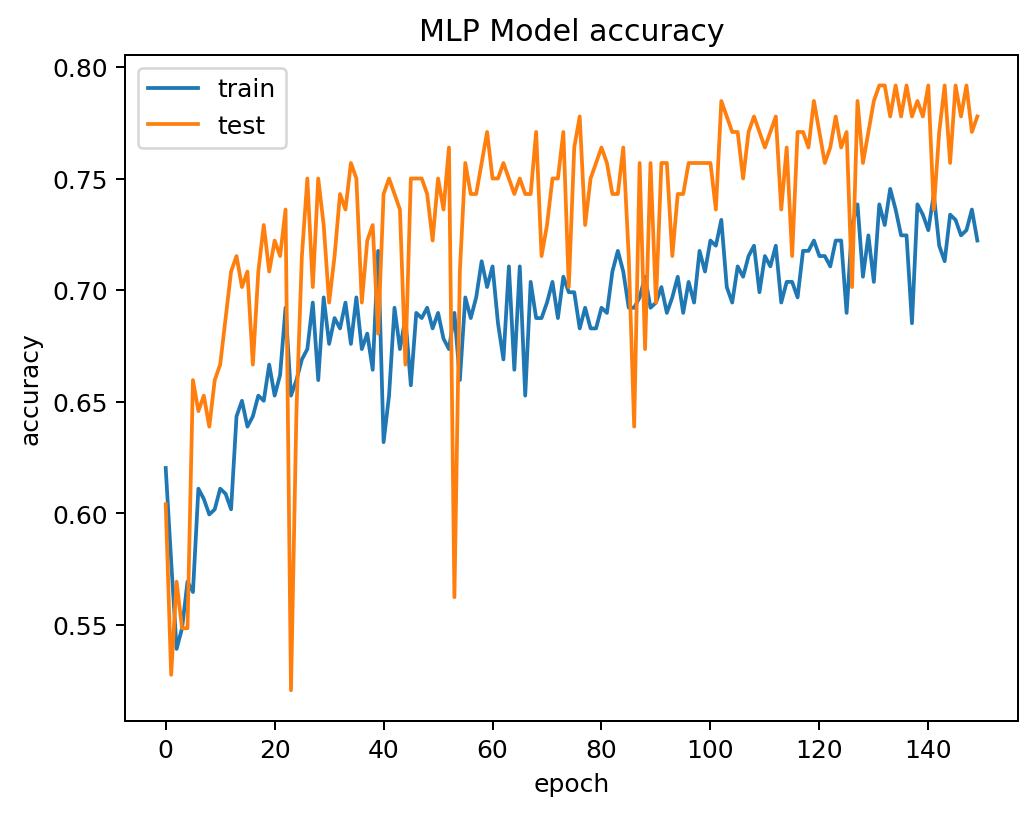

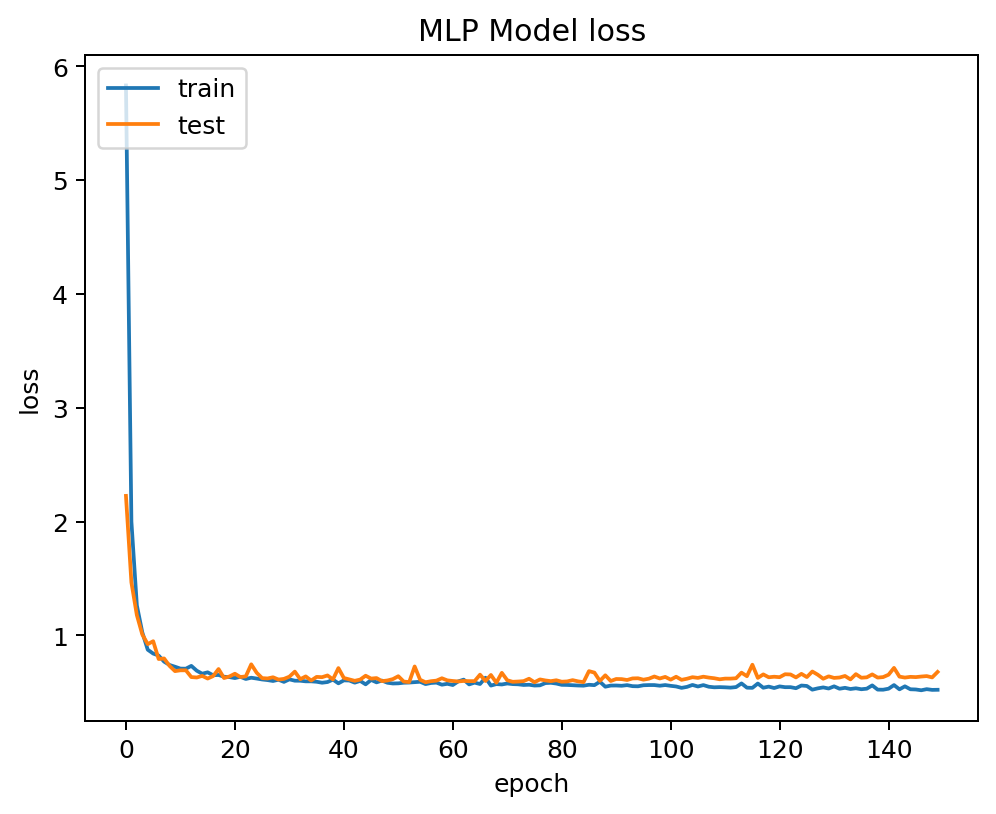

In [18]:
show_learning_curves(learning_evolution, 'MLP ')

Note that a cross-validated testing accuracy slightly higher than training accuracy can indicate that the internal settings for promoting generalization works well!

***
## Evaluate model

In [19]:
# aim to zero loss and 100% accuracy
#
loss, accuracy = MLP_model.evaluate(X_test, Y_test)
print('Accuracy: {:.2f}% - Loss {:.2f}'.format(accuracy*100, loss))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 760us/step - accuracy: 0.6953 - loss: 0.6853
Accuracy: 72.40% - Loss 0.69


***
## Make predictions 

We are using a sigmoid activation function on the output layer, such that  the predictions will be in the range between 0 and 1. Therefore, they can be  interpreted as **probabilities**. 

In fact, the method `predict()` (or `predict_proba()`) returns probabilities (of the input to belong to the given class, it might be a bit faulty), while `predict_classes()` returns the class.


In [20]:
# make probability predictions with the model
n_test = 12
Y_pred_probs   = MLP_model.predict(X_test[0:n_test])
#Y_pred_classes = MLP_model.predict_classes(X_test[0:n_test]) # removed from 2.6
Y_pred_classes = (MLP_model.predict(X_test[0:n_test]) > 0.5).astype("int32")

print('{} Predicted class (with probability) {}\n'.format('*'*5, '*'*5))
for i in range(n_test):
    true_label = Y_test[i] 
    predicted_class = int(Y_pred_classes[i])
    prediction_prob = float(Y_pred_probs[i])
    print('Input [class {}] -> Output: {} ({:.3f})\n'.format(true_label, 
                                                             predicted_class,
                                                             prediction_prob))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
***** Predicted class (with probability) *****

Input [class 1] -> Output: 0 (0.006)

Input [class 0] -> Output: 0 (0.212)

Input [class 0] -> Output: 0 (0.160)

Input [class 0] -> Output: 0 (0.382)

Input [class 1] -> Output: 0 (0.130)

Input [class 1] -> Output: 1 (0.773)

Input [class 0] -> Output: 1 (0.922)

Input [class 0] -> Output: 0 (0.360)

Input [class 0] -> Output: 0 (0.460)

Input [class 1] -> Output: 0 (0.229)

Input [class 0] -> Output: 0 (0.378)

Input [class 1] -> Output: 0 (0.492)



/var/folders/56/bp222b7x7qs_nsddnk9w__5m0000gp/T/ipykernel_79724/2170385442.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predicted_class = int(Y_pred_classes[i])
/var/folders/56/bp222b7x7qs_nsddnk9w__5m0000gp/T/ipykernel_79724/2170385442.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  prediction_prob = float(Y_pred_probs[i])


***
## Comparison with other estimators: SVC

In [21]:
from sklearn import metrics
from sklearn.svm import SVC

clf = SVC(kernel='linear', C=1.0, tol=0.1, verbose=True)

clf.fit(X_train, Y_train)

Y_pred = clf.predict(X_test)

accuracy = metrics.accuracy_score(Y_test, Y_pred)

print('\n*** Accuracy {}: {:.3f} ***'.format(clf.__class__.__name__, accuracy))
    
#show_confusion_matrix(Y_test, Y_pred, ['0', '1'])

[LibSVM]..............................................................................................................................................................................................................................................................................................................................................
.....................................................................................................................................*...........................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................

A comparable, performance (in a mush shorter time, indeed!)

***
## SVC *learning* curve

This might take some time.

In [22]:
# the code below, commented, doesn't work, the problem is that libSVM publishes its log on stdout, 
# which is not being displayed inside a notebook, therefore verbose doesn't print
# anything. 
# Running the code in a shell scripts show that #iter = 3.5M
#
#import sys
#sys.stdout=open("svc.log","w")
#print ("this is a log message")
#clf = SVC(kernel='linear', C=1.0, tol=0.1, verbose=True)
#sys.stdout.close()

def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

#import warnings
#warnings.filterwarnings("ignore", category=ConvergenceWarning)

accuracy = []
iterations = []
for i in range(10000, 350 * 10000, 100000):
    clf = SVC(kernel='linear', C=1.0, tol=0.1, max_iter = i)

    clf.fit(X_train, Y_train)

    Y_pred = clf.predict(X_test)

    accuracy.append(metrics.accuracy_score(Y_test, Y_pred))
    iterations.append(i)
    

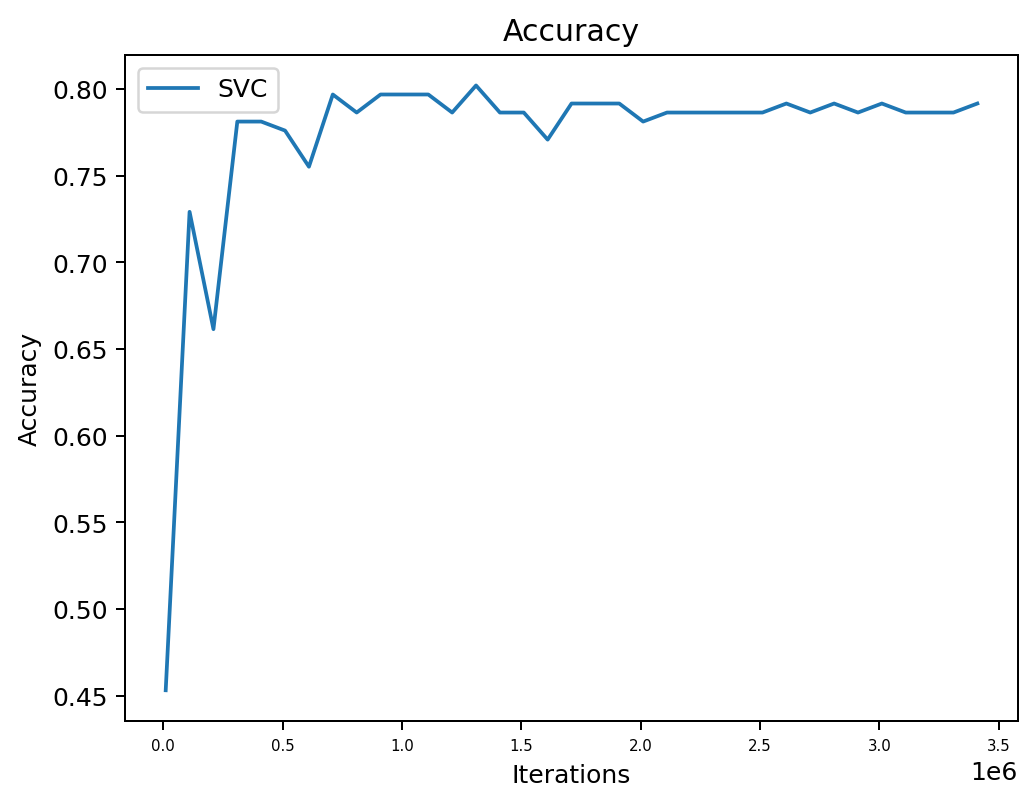

In [23]:
plt.title('Accuracy')
plt.plot(iterations, accuracy, label='SVC')
plt.xticks(fontsize=6)
plt.xlabel('Iterations')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

***
## Increase the complexity of the NN model


***
### Make it deeper

In [24]:
MLP_model = Sequential()

MLP_model.add(Input(shape=(8,)))  

MLP_model.add(Dense(12, use_bias=True, activation='relu'))

MLP_model.add(Dense(12, use_bias=True, activation='relu')) 
MLP_model.add(Dense(12, use_bias=True, activation='relu')) 
MLP_model.add(Dense(8, use_bias=True, activation='relu')) 
MLP_model.add(Dense(1, use_bias=True, activation='sigmoid'))  

In [25]:
MLP_model.compile(loss='binary_crossentropy', optimizer='adam', 
                  metrics=['accuracy'])

In [26]:
learning_evolution = MLP_model.fit(X_train, Y_train, epochs=200, batch_size=15,
                                  validation_split=0.25)

Epoch 1/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6321 - loss: 5.2321 - val_accuracy: 0.6458 - val_loss: 1.6902
Epoch 2/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 967us/step - accuracy: 0.5362 - loss: 1.6283 - val_accuracy: 0.5625 - val_loss: 1.0076
Epoch 3/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 964us/step - accuracy: 0.5296 - loss: 1.0289 - val_accuracy: 0.6389 - val_loss: 0.8037
Epoch 4/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 859us/step - accuracy: 0.6289 - loss: 0.7957 - val_accuracy: 0.6042 - val_loss: 0.7757
Epoch 5/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 848us/step - accuracy: 0.6602 - loss: 0.6997 - val_accuracy: 0.6181 - val_loss: 0.7465
Epoch 6/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 845us/step - accuracy: 0.5704 - loss: 0.7086 - val_accuracy: 0.6111 - val_loss: 0.7276
Epoch 7/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 905us/step - accuracy: 0.6387 - loss: 0.6548 - val_accuracy: 0.6181 - val_loss: 0.7017
Epoch 8/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 855us/step - accuracy: 0.6128 - loss: 0.6489 - val_accura

Stored information: ['accuracy', 'loss', 'val_accuracy', 'val_loss']


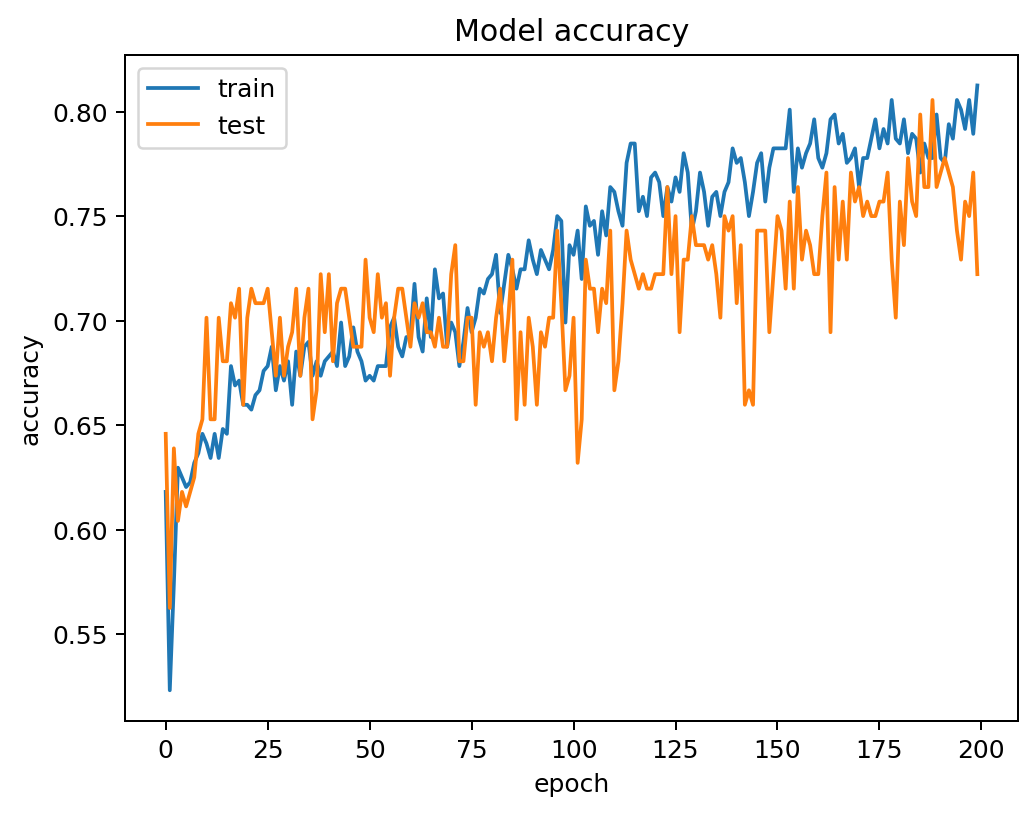

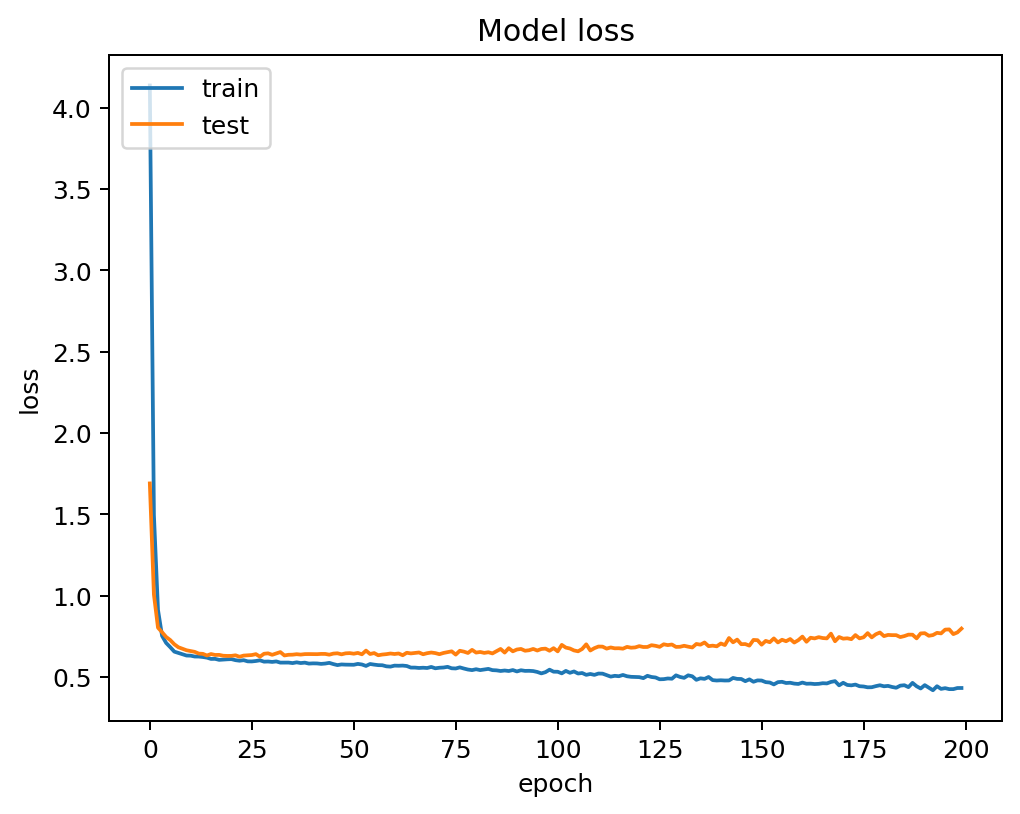

In [27]:
show_learning_curves(learning_evolution)

In [28]:
# aim to zero loss and 100% accuracy
#
loss, accuracy = MLP_model.evaluate(X_test, Y_test)
print('Accuracy: {:.2f}% - Loss {:.2f}'.format(accuracy*100, loss))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7241 - loss: 0.7957 
Accuracy: 76.04% - Loss 0.87


It didn't improved! 

***
### Make it wider

In [29]:
MLP_model = Sequential()

MLP_model.add(Input(shape=(8,))) 
    
MLP_model.add(Dense(24, use_bias=True, activation='relu'))
MLP_model.add(Dense(12, use_bias=True, activation='relu')) 
MLP_model.add(Dense(8, use_bias=True, activation='relu')) 
MLP_model.add(Dense(1, use_bias=True, activation='sigmoid'))  

In [30]:
MLP_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [31]:
learning_evolution = MLP_model.fit(X_train, Y_train, epochs=200, batch_size=15,
                                  validation_split=0.25)

Epoch 1/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5886 - loss: 1.1072 - val_accuracy: 0.6389 - val_loss: 0.7684
Epoch 2/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 910us/step - accuracy: 0.5985 - loss: 0.8271 - val_accuracy: 0.6250 - val_loss: 0.7393
Epoch 3/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 886us/step - accuracy: 0.5956 - loss: 0.6989 - val_accuracy: 0.6319 - val_loss: 0.7101
Epoch 4/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 800us/step - accuracy: 0.6191 - loss: 0.6741 - val_accuracy: 0.6111 - val_loss: 0.7069
Epoch 5/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 802us/step - accuracy: 0.6228 - loss: 0.6563 - val_accuracy: 0.5764 - val_loss: 0.7057
Epoch 6/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 858us/step - accuracy: 0.6077 - loss: 0.6967 - val_accuracy: 0.5764 - val_loss: 0.7389
Epoch 7/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 785us/step - accuracy: 0.6110 - loss: 0.7588 - val_accuracy: 0.6597 - val_loss: 0.6942
Epoch 8/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 869us/step - accuracy: 0.6722 - loss: 0.6279 - val_accura

Stored information: ['accuracy', 'loss', 'val_accuracy', 'val_loss']


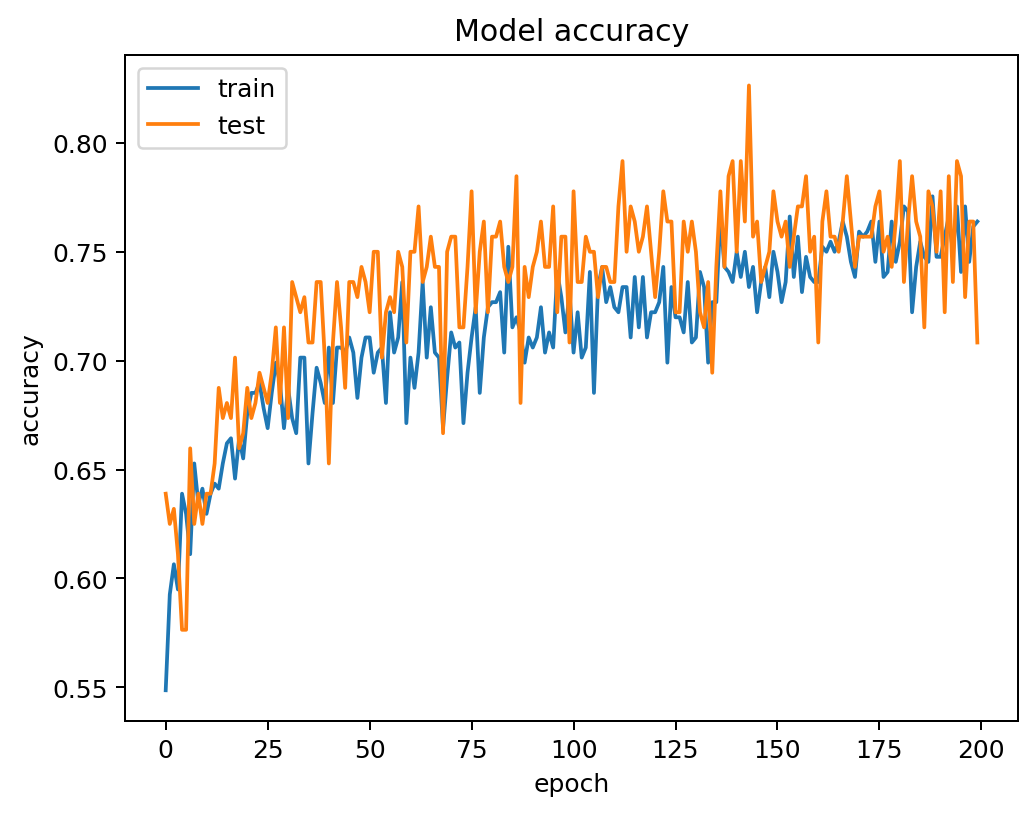

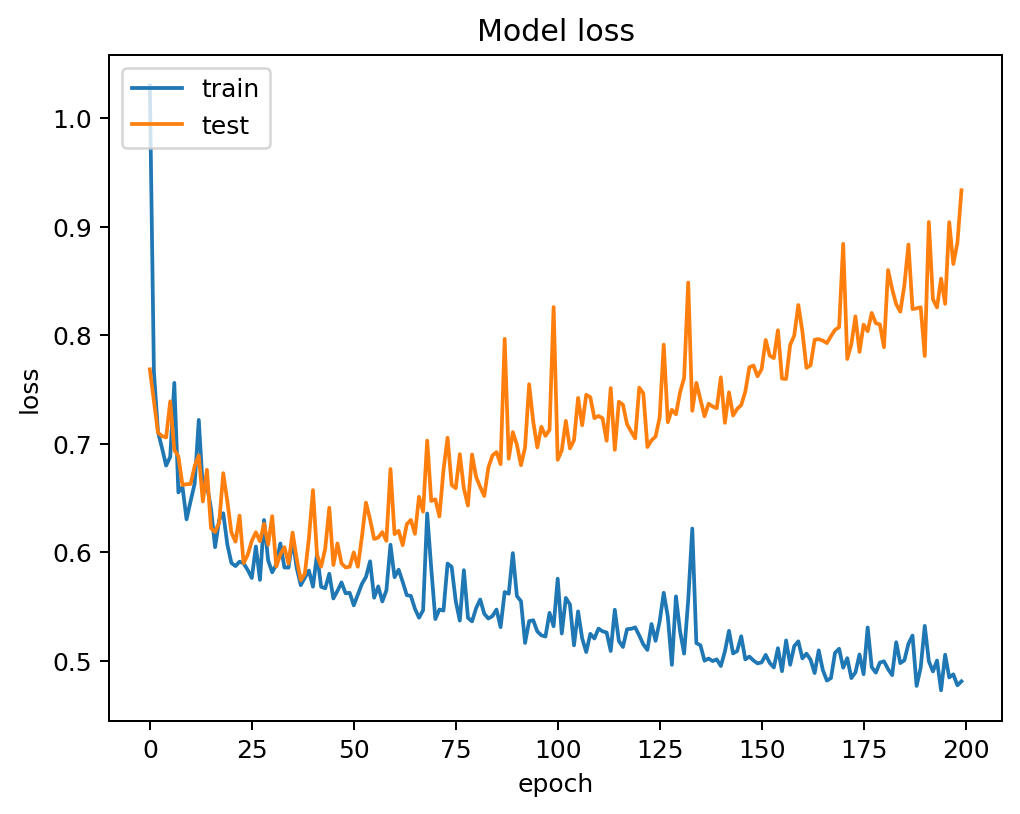

In [32]:
show_learning_curves(learning_evolution)

In [33]:
# aim to zero loss and 100% accuracy
#
loss, accuracy = MLP_model.evaluate(X_test, Y_test)
print('Accuracy: {:.2f}% - Loss {:.2f}'.format(accuracy*100, loss))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 952us/step - accuracy: 0.7059 - loss: 1.0930
Accuracy: 73.44% - Loss 1.12


***
# MLP model for MNIST image dataset

In [34]:
from keras.datasets import mnist
 
# Load pre-shuffled MNIST data into train and test sets
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

In [35]:
print(X_train.shape, Y_train.shape)
# (60000, 28, 28)

(60000, 28, 28) (60000,)


In [36]:
num_classes = 10 # classification of the digits from 0 to 9

In [37]:
nrows = X_train.shape[1]
ncols = X_train.shape[2]

class_names = [str(d) for d in range(10) ]

print('The dataset consists of {} images {}x{}'.format(X_train.shape[0], 
                                                       nrows, ncols))
class_names

The dataset consists of 60000 images 28x28


['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

In [38]:
# from HW!
def visualize_images(features_img, labels_img, img_size=(28, 28), 
                     img_titles='Digit', class_names = [],
                     n=15, selection='deterministic',
                     cmap='gray'):

    if n < 6:
        print('ERROR: Number of images to visualize must be greater than 5!\n')
        return
    
    # transform the flat arrays into 2D images
    features_img_viz = features_img.reshape(features_img.shape[0], 
                                            img_size[0], img_size[1])
    features_img_viz = features_img_viz.astype(np.uint8)

    ncols = 5
    nrows = int(np.ceil(n / ncols))
    
    width = 14
    height = 2 * nrows
    fig, subplots = plt.subplots(nrows, ncols, figsize=(width, height))
    fig.subplots_adjust(top=0.85, hspace=0.5)
    
    if selection == 'deterministic':
        selection = np.arange(0, nrows * ncols, 1)
        selection = selection.reshape(nrows, ncols)
        print(selection)
    else:
        selection = np.random.choice(list(range(features_img_viz.shape[0])), 
                                     size = nrows * ncols, replace=False)
        selection = selection.reshape(nrows, ncols)

    p = 0
    for r in range(nrows):
        for c in range(ncols): 
            if p >= n:
                subplots[r,c].axis('off')
            else:
                subplots[r,c].axis('off')
                title = '{} {}'.format(img_titles, 
                                        class_names[labels_img[selection[r,c]]])
                
                subplots[r,c].set_title('{} [{}]'.format(title, 
                                                       labels_img[selection[r,c]]), 
                                                       fontsize=8)
                subplots[r,c].imshow(features_img_viz[selection[r,c]], 
                                     cmap=cmap)
            p += 1
    plt.show()

[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]]


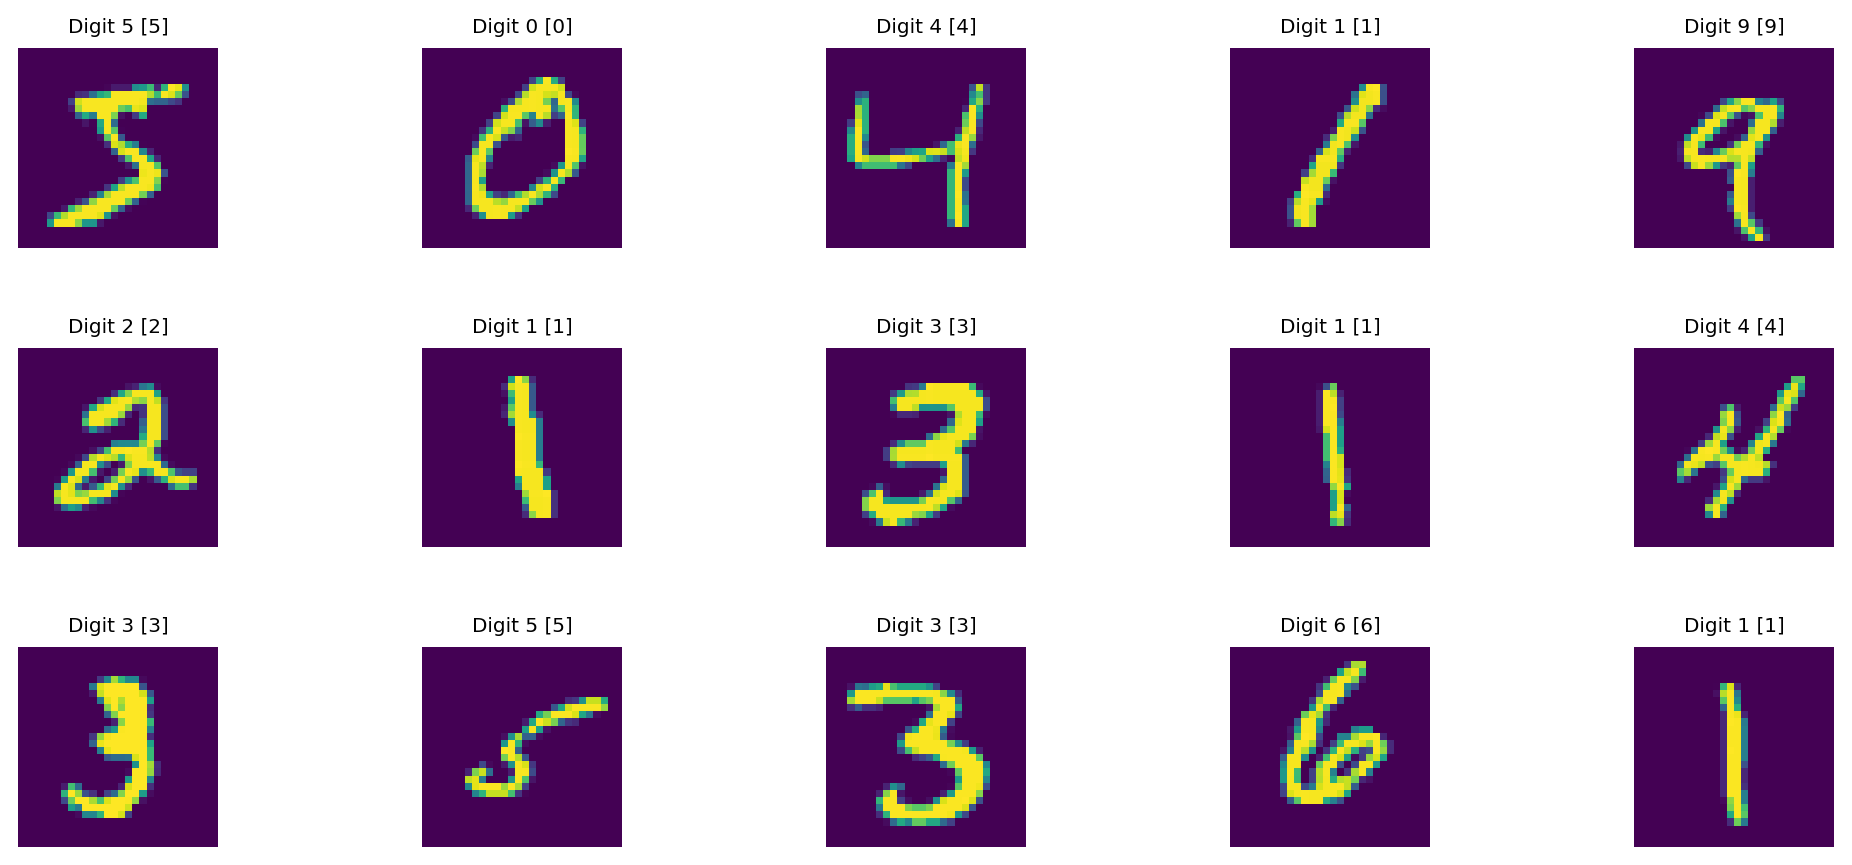

In [39]:
visualize_images(X_train, Y_train, img_size=(nrows, ncols), 
                 img_titles='Digit',
                 class_names = class_names,
                 n=15, selection='deterministic',
                 cmap='viridis')


***
## Preprocessing: Flatten the image arrays

In [40]:
X_train.shape

(60000, 28, 28)

For an MLP, an image is just a *flat* array, therefore we need to reshape the inputs

In [41]:
img_shape = nrows * ncols
X_train = X_train.reshape(-1,img_shape )
X_test  = X_test.reshape(-1, img_shape)

X_train.shape, X_test.shape

((60000, 784), (10000, 784))

***
## Preprocessing: Convert pixel intensities to [0,1]

Pixel intensities for the images are encoded as 8-bits integers, from 0 to 255.
Dealing with such a large, discrete scale is not appropriate for effective learning with a continuous function approximator such as an MLP. Therefore, a second and very important preprocessing step is to convert the image pixel intensities to the continuous range $[0, 1]$. 

At this aim, we have to divide the values by 255. However, to get the fractional division correct and have the data of the correct type, we need first to change to data type `float32` since it is originally `uint8`.

Note: check if the MLP can learn effectively skipping this preprocessing step! (No, it will not)

In [42]:
X_train.dtype

dtype('uint8')

In [43]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255

## Preprocessing: one-hot encoding for the labels

In [44]:
Y_train.shape

(60000,)

In [45]:
Y_train[0:15]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4, 3, 5, 3, 6, 1], dtype=uint8)

Labels are integer values between 0 and 9 (the digit). However, the output of our NN will be an array of 10 elements, each assigning a probability for the output being one of the digits. 

Therefore, it is necessary to modify the labels into a **one-hot array of 10 distinct class labels.**

In [46]:
# Convert 1-dimensional class arrays to 10-dimensional class matrices
Y_train = to_categorical(Y_train, 10)
Y_test = to_categorical(Y_test, 10)

In [47]:
Y_train.shape

(60000, 10)

***
## MLP architecture

In [49]:
'''
MLP_model = Sequential([
    Input(shape=(img_shape,)), 
    Dense(512, activation='relu'),
    Dropout(0.2),
    Dense(512, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])
'''

from keras.models import Model

# Functional API model definition for showing the layers, otherwise gets an error
inputs = Input(shape=(img_shape,))
x = Dense(512, activation='relu')(inputs)
x = Dropout(0.2)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.2)(x)
outputs = Dense(10, activation='softmax')(x)

MLP_model = Model(inputs=inputs, outputs=outputs)

# Call the model once to make sure it's built
_ = MLP_model.predict(X_train[:1])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


**Dropout?**
$\to$ A form of *regularization* aiming to support generalization / avoid overfitting.

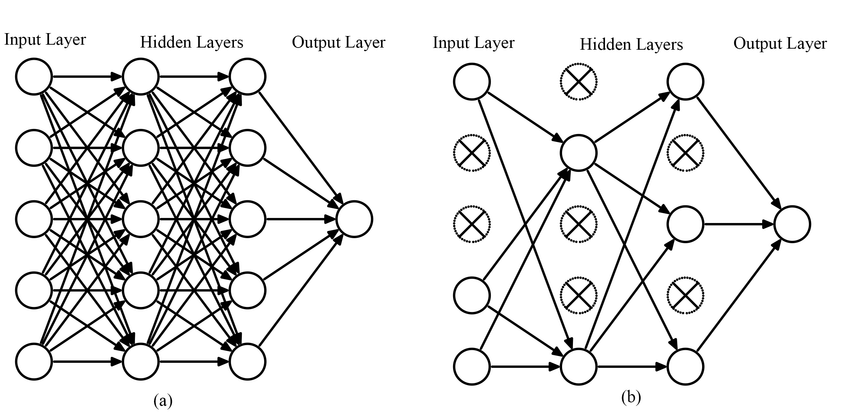

***
## Summary and Visualization of the model

In [50]:
MLP_model.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 669,706 (2.55 MB)

 Trainable params: 669,706 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

In [51]:
print(MLP_model.name)  

functional_12


In [52]:
import pydot
import pydotplus
keras.utils.pydot = pydot
from keras.utils import plot_model

plot_model(MLP_model, show_shapes=True, show_layer_names=True,
          dpi=100) #to_file='model_plot.png', 

***
## Compile the MLP model

In [53]:
MLP_model.compile(loss='categorical_crossentropy', 
                  optimizer='sgd', metrics=['accuracy'])

***
## Train the MLP model

In [54]:
X_train.shape

(60000, 784)

In [55]:
# let's use of 30% of the dataset, to speed up!
n_data_train = int(0.75 * X_train.shape[0])
n_data_test = int(0.75 * X_test.shape[0])

In [56]:
# Train
batch_size = 10
epochs = 25

start_time = time.process_time()

training = MLP_model.fit(X_train[0:n_data_train], Y_train[0:n_data_train], 
                         batch_size=batch_size, 
                         epochs=epochs, 
                         validation_data=(X_test[0:n_data_test], 
                                          Y_test[0:n_data_test]),
                         verbose=2)
                         #callbacks=[checkpointer, early_stopping], 

print('\n\nTraining time: {:.3f} sec\n'.format(time.process_time() - start_time))


Epoch 1/25
4500/4500 - 7s - 2ms/step - accuracy: 0.8634 - loss: 0.4700 - val_accuracy: 0.9288 - val_loss: 0.2468
Epoch 2/25
4500/4500 - 9s - 2ms/step - accuracy: 0.9332 - loss: 0.2277 - val_accuracy: 0.9467 - val_loss: 0.1788
Epoch 3/25
4500/4500 - 9s - 2ms/step - accuracy: 0.9508 - loss: 0.1684 - val_accuracy: 0.9568 - val_loss: 0.1445
Epoch 4/25
4500/4500 - 9s - 2ms/step - accuracy: 0.9607 - loss: 0.1344 - val_accuracy: 0.9627 - val_loss: 0.1236
Epoch 5/25
4500/4500 - 13s - 3ms/step - accuracy: 0.9676 - loss: 0.1113 - val_accuracy: 0.9671 - val_loss: 0.1099
Epoch 6/25
4500/4500 - 11s - 2ms/step - accuracy: 0.9710 - loss: 0.0967 - val_accuracy: 0.9699 - val_loss: 0.0982
Epoch 7/25
4500/4500 - 10s - 2ms/step - accuracy: 0.9750 - loss: 0.0846 - val_accuracy: 0.9685 - val_loss: 0.0982
Epoch 8/25
4500/4500 - 9s - 2ms/step - accuracy: 0.9780 - loss: 0.0741 - val_accuracy: 0.9729 - val_loss: 0.0903
Epoch 9/25
4500/4500 - 9s - 2ms/step - accuracy: 0.9808 - loss: 0.0644 - val_accuracy: 0.9737

In [57]:
# Train
batch_size = 128
epochs = 40

start_time = time.process_time()

training = MLP_model.fit(X_train[0:n_data_train], Y_train[0:n_data_train], 
                         batch_size=batch_size, 
                         epochs=epochs, 
                         validation_data=(X_test[0:n_data_test], 
                                          Y_test[0:n_data_test]),
                         verbose=2)
                         #callbacks=[checkpointer, early_stopping], 

print('\n\nTraining time: {:.3f} sec\n'.format(time.process_time() - start_time))


Epoch 1/40
352/352 - 2s - 5ms/step - accuracy: 0.9964 - loss: 0.0134 - val_accuracy: 0.9795 - val_loss: 0.0670
Epoch 2/40
352/352 - 2s - 4ms/step - accuracy: 0.9971 - loss: 0.0126 - val_accuracy: 0.9799 - val_loss: 0.0673
Epoch 3/40
352/352 - 2s - 4ms/step - accuracy: 0.9970 - loss: 0.0128 - val_accuracy: 0.9800 - val_loss: 0.0667
Epoch 4/40
352/352 - 1s - 4ms/step - accuracy: 0.9973 - loss: 0.0116 - val_accuracy: 0.9800 - val_loss: 0.0670
Epoch 5/40
352/352 - 2s - 5ms/step - accuracy: 0.9973 - loss: 0.0113 - val_accuracy: 0.9801 - val_loss: 0.0669
Epoch 6/40
352/352 - 1s - 4ms/step - accuracy: 0.9970 - loss: 0.0119 - val_accuracy: 0.9804 - val_loss: 0.0668
Epoch 7/40
352/352 - 1s - 4ms/step - accuracy: 0.9970 - loss: 0.0114 - val_accuracy: 0.9805 - val_loss: 0.0668
Epoch 8/40
352/352 - 1s - 4ms/step - accuracy: 0.9972 - loss: 0.0117 - val_accuracy: 0.9797 - val_loss: 0.0672
Epoch 9/40
352/352 - 2s - 4ms/step - accuracy: 0.9976 - loss: 0.0108 - val_accuracy: 0.9804 - val_loss: 0.0673
E

In [58]:
score = MLP_model.evaluate(X_test, Y_test, verbose=0)

print('Test score:', score[0])
print('Test accuracy:', score[1])

Test score: 0.058845292776823044
Test accuracy: 0.9829000234603882


***
## Show learning curves

Stored information: ['accuracy', 'loss', 'val_accuracy', 'val_loss']


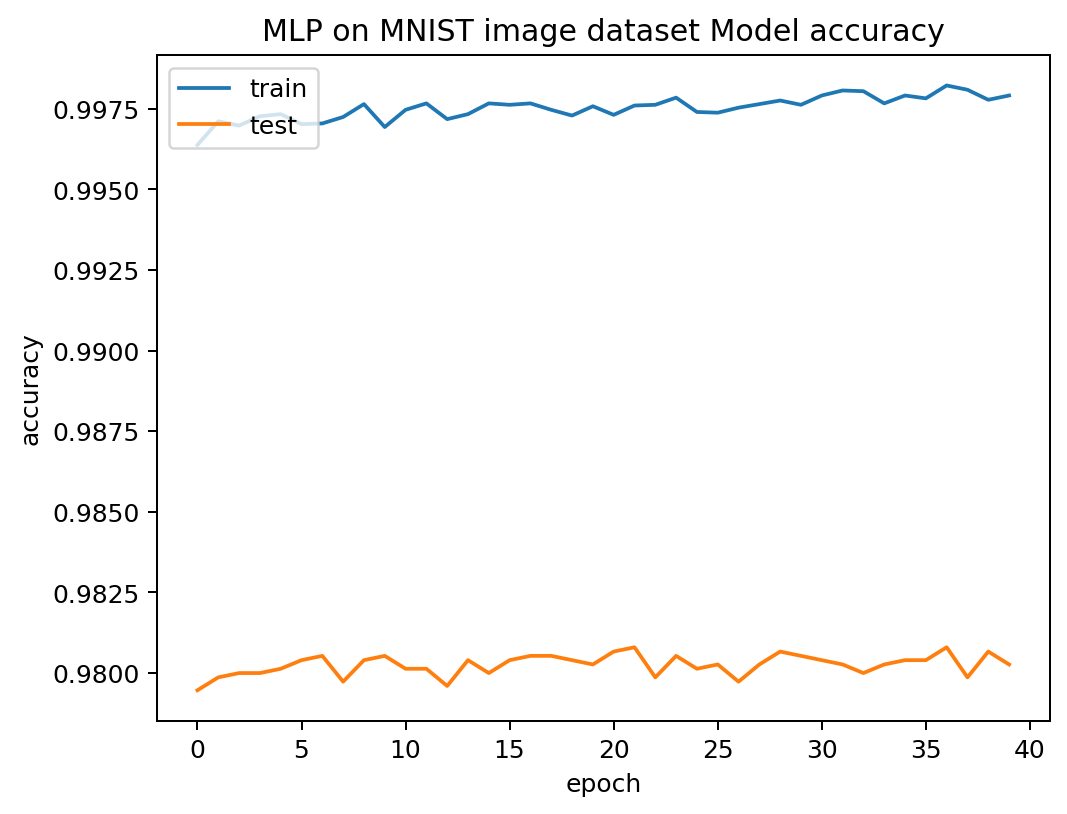

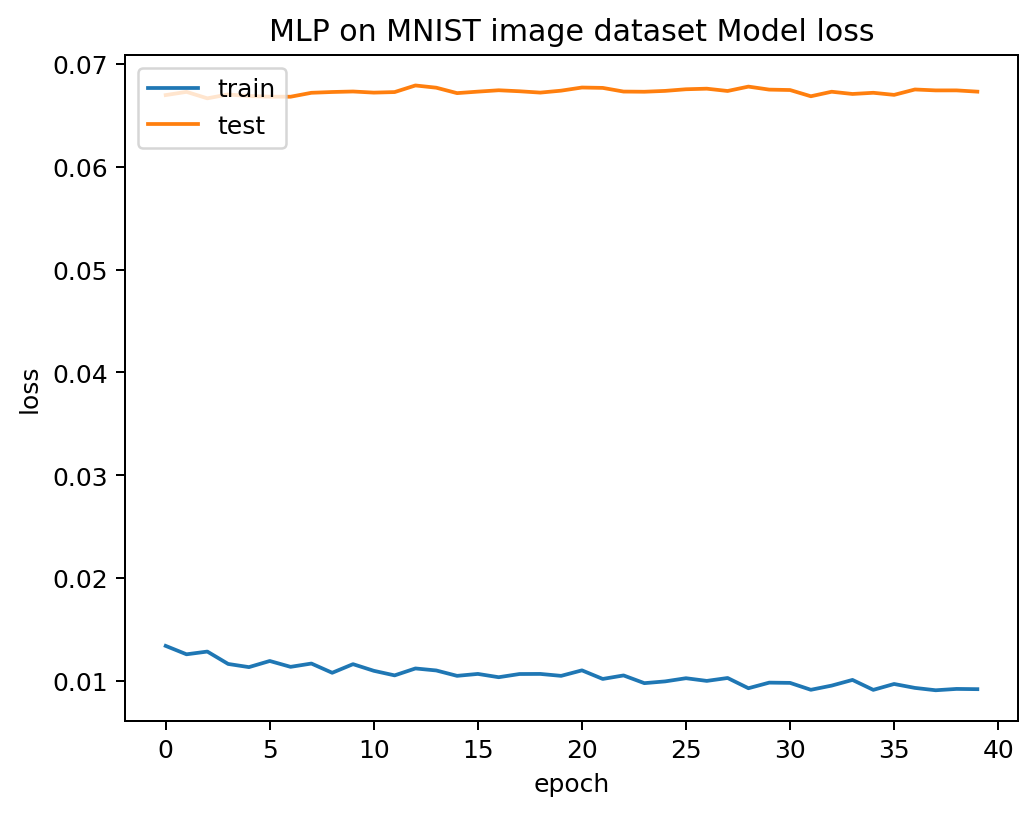

In [59]:
show_learning_curves(training, 'MLP on MNIST image dataset ')

***
## Make predictions 

We are using a softmax activation function on the output layer, such that  the predictions will be in the range between 0 and 1. Therefore, they can be  interpreted as **probabilities**. 

In fact, the method `predict()` returns probabilities, while `predict_classes()` returns the class (the result of `np.argmax()`)


In [60]:
# make probability predictions with the model
n_test = 12
Y_pred_probs   = MLP_model.predict(X_test[0:n_test])
Y_pred_classes = np.argmax(Y_pred_probs, axis=1)

print('{} Predicted class (with probability) {}\n'.format('*'*5, '*'*5))
for i in range(n_test):
    true_label = int(np.where(Y_test[i] > 0)[0])
    predicted_class = Y_pred_classes[i]
    prediction_prob = Y_pred_probs[i, predicted_class]
    print('Input [class {}] -> Output: {} ({:.2f})\n'.format(true_label, 
                                                             predicted_class,
                                                             prediction_prob))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
***** Predicted class (with probability) *****

Input [class 7] -> Output: 7 (1.00)

Input [class 2] -> Output: 2 (1.00)

Input [class 1] -> Output: 1 (1.00)

Input [class 0] -> Output: 0 (1.00)

Input [class 4] -> Output: 4 (1.00)

Input [class 1] -> Output: 1 (1.00)

Input [class 4] -> Output: 4 (0.99)

Input [class 9] -> Output: 9 (1.00)

Input [class 5] -> Output: 6 (0.74)

Input [class 9] -> Output: 9 (1.00)

Input [class 0] -> Output: 0 (1.00)

Input [class 6] -> Output: 6 (1.00)



/var/folders/56/bp222b7x7qs_nsddnk9w__5m0000gp/T/ipykernel_79724/3291794420.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  true_label = int(np.where(Y_test[i] > 0)[0])


## Confusion matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 858us/step


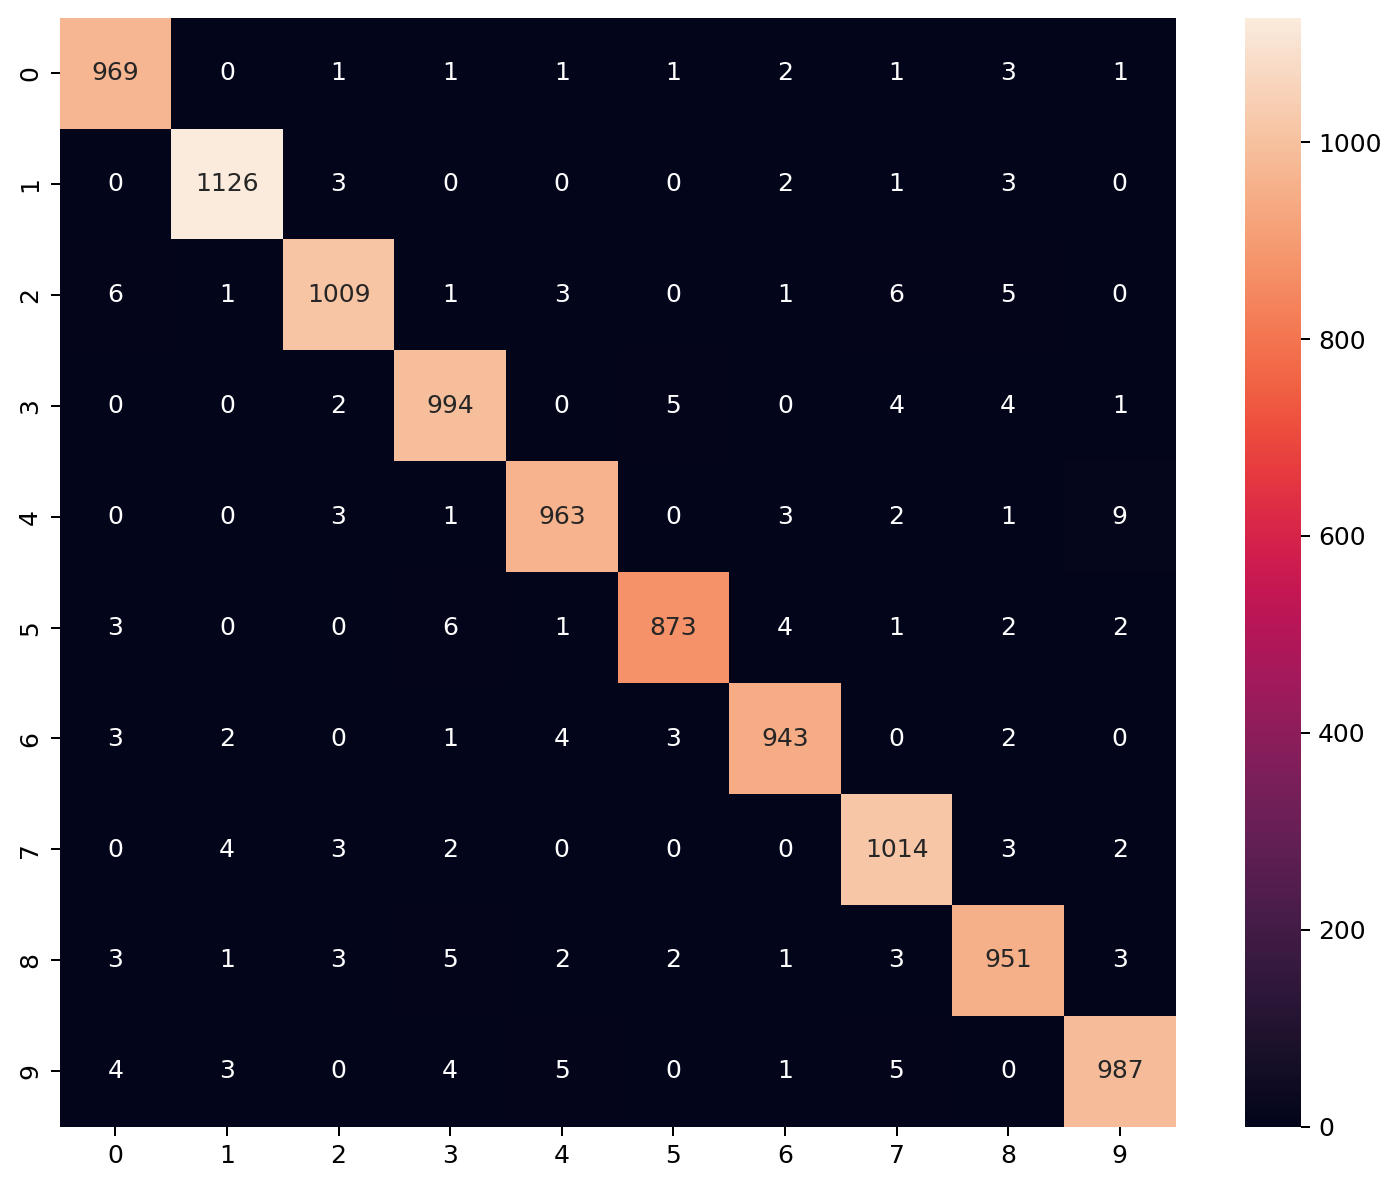

In [61]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

Y_prediction = MLP_model.predict(X_test)

# Convert predictions classes to one hot vectors 
Y_pred_classes = np.argmax(Y_prediction, axis = 1)

# Convert test data to one hot vectors
Y_true = np.argmax(Y_test, axis = 1) 

# compute the confusion matrix
confusion_mtx = confusion_matrix(Y_true, Y_pred_classes) 

plt.figure(figsize=(10,8))
sns.heatmap(confusion_mtx, annot=True, fmt="d");

***
## Show feature maps

Each layer acts as a feature extractor, it learns a **feature map,** with the feature maps being more and more abstract and global(aggregate) with the depth of the layers in the network.

Get the information from the trained layers, including name and weights.

A sample image from the dataset is then passed to the network to classify. The activations (feature maps) from each functional layer are shown. 

Get the information from the trained layers, including name and weights.

A sample image from the dataset is then passed to the network to classify. The activations (feature maps) from each functional layer are shown. 

In [62]:
from keras.models import Model

layer_outputs = [layer.output for layer in MLP_model.layers]

layer_names = [layer.name.split('_')[0] for layer in MLP_model.layers]

print(layer_outputs)

activation_model = keras.Model(inputs=MLP_model.input, outputs=layer_outputs)

idx = 7
img_sample = X_train[idx:idx+1]

activations = activation_model.predict(img_sample)
print('Sample image is a {} and is classified as {}'.format(np.argmax(Y_train[idx]),
                                                        np.argmax(activations[-1])))

for a,_ in enumerate(activations):
    print('Activation Layer [{}]: {} {}'.format(a, layer_names[a],
                                                activations[a].shape))

[<KerasTensor shape=(None, 784), dtype=float32, sparse=False, name=keras_tensor_40>, <KerasTensor shape=(None, 512), dtype=float32, sparse=False, name=keras_tensor_41>, <KerasTensor shape=(None, 512), dtype=float32, sparse=False, name=keras_tensor_42>, <KerasTensor shape=(None, 512), dtype=float32, sparse=False, name=keras_tensor_43>, <KerasTensor shape=(None, 512), dtype=float32, sparse=False, name=keras_tensor_44>, <KerasTensor shape=(None, 10), dtype=float32, sparse=False, name=keras_tensor_45>]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Sample image is a 3 and is classified as 3
Activation Layer [0]: input (1, 784)
Activation Layer [1]: dense (1, 512)
Activation Layer [2]: dropout (1, 512)
Activation Layer [3]: dense (1, 512)
Activation Layer [4]: dropout (1, 512)
Activation Layer [5]: dense (1, 10)


In [63]:
def display_activation(activations, activation_index, 
                       ncols = 5, 
                       size=(12, 12), reshape=None): 
    
    activation = activations[activation_index]

    print('Shape of layer: ', activation.shape)
    
    if len(activation.shape) > 2:
        total_fmaps = activation.shape[-1] # the last axis of the array
        nrows = int(np.ceil(total_fmaps / ncols))
    else:
        total_fmaps = 1
        nrows,ncols = (1,1)

    feature_map=0
    
    if (ncols, nrows) == (1,1):
        plt.yticks([], [])
        plt.xticks(fontsize=6)
        if reshape == None:
            plt.imshow(activation[0].reshape(-1,1).T) #cmap='gray')
        else:
            plt.imshow(activation[0].reshape(reshape).T)
        return
        
    #fig, subplot = plt.subplots(nrows, ncols, figsize=size)
    fig = plt.figure(figsize=size)
    fig.subplots_adjust(hspace=0.23, wspace=0.22)
    
    for row in range(nrows):
        for col in range(ncols):
            subplot = fig.add_subplot(nrows, ncols, feature_map+1) 
            #subplot[row][col].imshow(activation[0, :, :, feature_map], 
            #                         cmap='gray')
            #subplot[row][col].tick_params(labelsize = 3)
            subplot.imshow(activation[0, :, :, feature_map])# cmap='gray')
            subplot.tick_params(labelsize = 3)    
            
            feature_map += 1
            if feature_map == total_fmaps:
                return


Type of layer:  dropout
Shape of layer:  (1, 512)


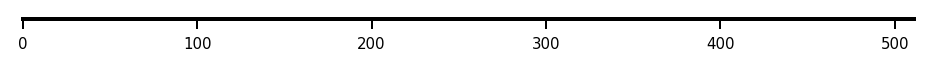

In [64]:
layer = 4
print('Type of layer: ', layer_names[layer])
display_activation(activations, layer, 6, (12,12))

In [65]:
28*28

784

Type of layer:  input
Shape of layer:  (1, 784)


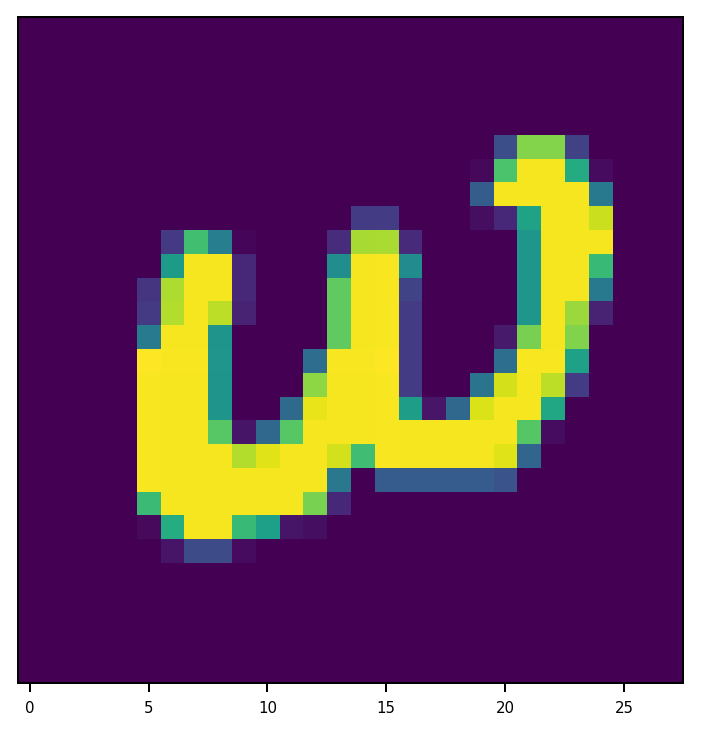

In [66]:
layer = 0
print('Type of layer: ', layer_names[layer])
display_activation(activations, layer, 6, (12,12), reshape=(28,28))

Type of layer:  dense
Shape of layer:  (1, 512)


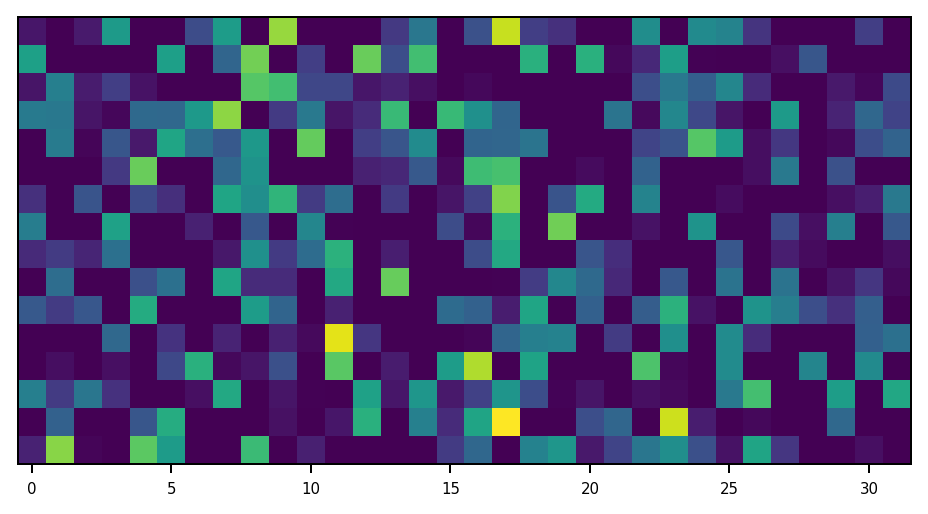

In [67]:
layer = 3
print('Type of layer: ', layer_names[layer])
display_activation(activations, layer, 6, (12,12), reshape=(32,16))

It looks pretty random .... feature extraction happens but it is not really like in the case of CNN that have a specific structure that is precisely designed after image data.